# Doc2Vec
- Word2Vec의 확장판 모델
- 기본적인 매개변수, 속성, 메서드는 Word2Vec과 같다
- 추가적인 부분이 생성

- 매개변수
    - dm
        - 기본값 : 1
        - 학습 알고리즘 선택
        - 1 : PV-DM
        - 0 : PV-DBOW
    - dm_mean
        - 기본값 : 0
        - PV-DM에서 문서 벡터의 계산 방식
        - 0: 벡터들의 합산 -> 범위가 커지는 경우가 발생 ->
        노이즈로 인한 성능의 저하가 발생 할수 있음
        - 1: 벡터들의 평균
    - dm_concat
        - 기본값 : 0
        - PV-DM에서 문서 벡터와 문장 벡터를 결합할 것인가
        - 결합을 하는 경우 차원이 급격하게 증가
    - dbow_words
        - 기본값 : 0
        - PV-DBOW 사용 시 단어 벡터도 동시에 학습할것인가
        (Skip-gram 방식과 흡사)
- 속성
    - model.wv
        - 학습이 된 단어 벡터의 저장소
    - model.dv
        - 학습이 된 문장의 벡터의 저장소
    - model.dv.index_to_key
        - 문서들의 ID값 리스트
- 메서드
    - build_vocab()
        - 단어 / 문서 사전을 구성
    - train()
        - 사전이 구축이 된 뒤 직접 학습을 수행
- build_vocab(), train() 메서드를 이용하여 수동으로 학습을 설정
- 일반적으로는 Doc2Vec 객체를 생성할때 사전의 생성과 학습
- 증분 학습에서 사용이 되는 부분
    - 기존에 학습이 된 모델에 새로운 데이터셋을 추가
    - 데이터에 양의 증가하면 성능이 오를 수 있는 확률이 존재
    - 기존의 학습 시킨 데이터와 유사한 데이터를 충분 학습하여 성능을 향상
    

In [1]:
# gensim 라이브러리안에 Doc2Vec를 이용하여 임베딩
from konlpy.tag import Komoran
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re

In [2]:
# 샘플 데이터 2개의 유형 문장들로 구성
docs = [
    "나는 커피를 정말 좋아한다",
    "오늘 아침에 에스프레소 두 잔을 마셨다",
    "카페라떼가 제일 맛있다고 생각한다",
    "나는 차를 더 자주 마신다",
    "녹차를 마시면 기분이 편안해진다",
    "홍차는 향이 깊고 고급스러운 느낌이다",
    "카페에서 책을 읽는 시간이 너무 좋다",
    '허브티도 몸에 좋은거 같다'
]

In [8]:
# 형태소 분석 Komoran을 이용하여 토큰화
komoran = Komoran()

# 특정 품사만 사용
allow_pos = ['NNP','NNG','VV','VA','MAG']
# 불용어
stop_word = ['하다','되다','이다','것','수','거']

def normalize(text):
    # [^...]는 '...'를 제외한 모든 문자를 의미합니다.
    # 즉, 한글, 숫자, 영문, 공백, '.'을 *제외한* 모든 특수문자를 공백(" ")으로 바꿉니다.
    text = re.sub(r"[^가-힣0-9a-zA-Z\s\.]", " ", text)
    
    # 여러 개의 공백을 하나의 공백으로 줄이고, 양쪽 끝 공백을 제거합니다.
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# 토큰화 함수를 정의
def tokenize(text):
    # 문자의 정규화 함수를 호출
    text = normalize(text)

    tokens = []
    for word, pos in komoran.pos(text):
        if pos in allow_pos:
            if word not in stop_word and len(word) > 1:
                # allow_pos의 포함되어있고
                # stop_word에 포함되어있지 않으며
                # 단어의 길이가 1보다 큰 문자만 활용
                tokens.append(word)
    return tokens

In [9]:
tokenize_docs = [tokenize(doc) for doc in docs]
tokenize_docs

[['커피', '정말', '좋아하'],
 ['오늘', '아침', '에스프레소', '마시'],
 ['카페', '제일', '맛있', '생각'],
 ['자주', '마시'],
 ['녹차', '마시', '기분', '편안'],
 ['홍차', '고급', '느낌'],
 ['카페', '시간', '너무'],
 ['허브']]

In [11]:
# 문장 별로 ID를 지정
tagged = []
for idx, toks in enumerate(tokenize_docs):
    tagged.append(
        TaggedDocument(words = toks, tags= [f"DOC_{idx}"])
    )
tagged

[TaggedDocument(words=['커피', '정말', '좋아하'], tags=['DOC_0']),
 TaggedDocument(words=['오늘', '아침', '에스프레소', '마시'], tags=['DOC_1']),
 TaggedDocument(words=['카페', '제일', '맛있', '생각'], tags=['DOC_2']),
 TaggedDocument(words=['자주', '마시'], tags=['DOC_3']),
 TaggedDocument(words=['녹차', '마시', '기분', '편안'], tags=['DOC_4']),
 TaggedDocument(words=['홍차', '고급', '느낌'], tags=['DOC_5']),
 TaggedDocument(words=['카페', '시간', '너무'], tags=['DOC_6']),
 TaggedDocument(words=['허브'], tags=['DOC_7'])]

In [12]:
# tag를 추가한 문서를 이용해서 Doc2Vec 모델에 학습 데이터로 이용
model = Doc2Vec(
    documents= tagged,
    vector_size= 120,
    window= 5,
    min_count = 1,
    dm=1,
    dm_mean=1,
    negative=5,
    epochs=50,
    seed= 42
)

In [13]:
print("학습이 된 문장의 개수", len(model.dv))

학습이 된 문장의 개수 8


In [16]:
# 문장 간으 유사도를 수치적으로 확인
def print_similities(doc_id):
    dic_vec = model.dv[f"DOC_{doc_id}"]
    # doc_id : 문서의 tag 이름
    # 각각의 문장들의 벡터 데이터를 리스트로 생성
    mat = np.vstack(
        [model.dv[f"DOC_{i}"] for i in range(len(docs))]
    )
    # 코사인 유사도 사용
    sims = cosine_similarity( [dic_vec], mat )[0]
    order = sims.argsort()[::-1]
    print(f"기존의 문장 : {doc_id} -> {docs[doc_id]}")
    for idx in order:
        print(f"  -> {idx} {docs[idx]}  |  cos = {sims[idx]}")

print_similities(0)

기존의 문장 : 0 -> 나는 커피를 정말 좋아한다
  -> 0 나는 커피를 정말 좋아한다  |  cos = 1.0
  -> 7 허브티도 몸에 좋은거 같다  |  cos = 0.18403789401054382
  -> 1 오늘 아침에 에스프레소 두 잔을 마셨다  |  cos = 0.13299930095672607
  -> 3 나는 차를 더 자주 마신다  |  cos = 0.06536193192005157
  -> 4 녹차를 마시면 기분이 편안해진다  |  cos = 0.014882013201713562
  -> 6 카페에서 책을 읽는 시간이 너무 좋다  |  cos = 0.011992134153842926
  -> 2 카페라떼가 제일 맛있다고 생각한다  |  cos = -0.06253507733345032
  -> 5 홍차는 향이 깊고 고급스러운 느낌이다  |  cos = -0.12268492579460144


In [19]:
# 차원 축소 기법을 이용해서 그래프 시각화
# 각 문장들 간에 거리를 확인
from sklearn.manifold import TSNE

In [21]:
X = np.vstack(
    [model.dv[f"DOC_{idx}"] for idx in range(len(docs))]
)
X.shape

(8, 120)

In [22]:
# t-SNE 를 이용해서 차원축소
tsne = TSNE(
    n_components=2,
    perplexity=5,
    max_iter=2000,
    random_state=42
)

In [24]:
# 차원 축소 모델에 학습을 시키고 데이터를 변형한다
X_2d = tsne.fit_transform(X)

In [25]:
X_2d.shape

(8, 2)

In [27]:
import matplotlib.pyplot as plt


In [38]:
# 그래프는 산점도 그래프
# 각각의 점에 주석 추가 -> 해당 위치의 문장의 데이터
# 문장들이 한글 -> 기본적인 matplot에서는 한글 지원 x
# 폰트 변경
# 각각의 os에 따라서 폰트 설정이 다름
import platform

if platform.system() == 'Darwin':
    plt.rc('font', family = 'AppleGothic')
else:
    plt.rc('font', family = 'Malgun Gothic')
# 마이너스 깨짐 부호 방지
plt.rcParams['axes.unicode_minus'] = False

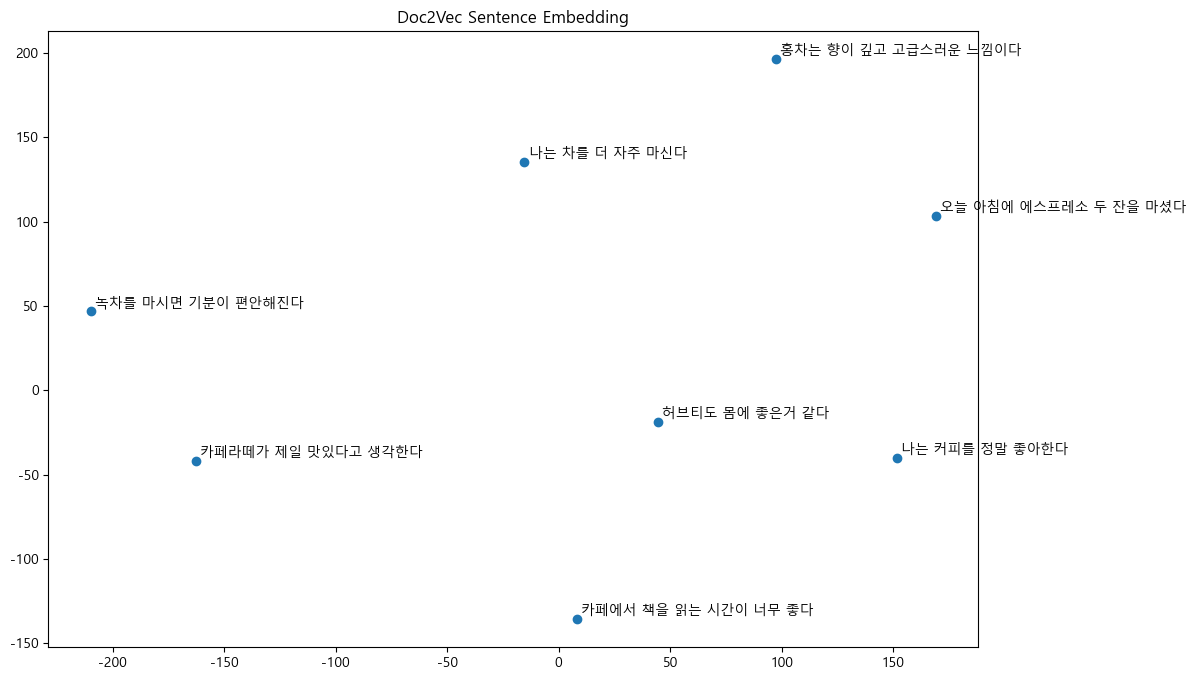

In [39]:
plt.figure(figsize=(12, 8))
# 산점도 그래프를 생성 -> X축 데이터, Y축 데이터
plt.scatter(X_2d[:, 0], X_2d[:, 1])

for idx, text in enumerate(docs):
    plt.annotate(
        text,
        # 주석의 원 데이터 위치
        xy= (X_2d[idx,0], X_2d[idx,1]),
        # 주석이 위치
        xytext= (3,3),
        textcoords='offset points' # 각각의 위치에 텍스트 대입
    )

plt.title("Doc2Vec Sentence Embedding")
plt.show()

In [40]:
# 문장 별 벡터의 값을 이용하여 기계 학습
# 학습 데이터(독립 변수) -> 문장별 벡터 데이터
# 타깃 데이터(종속 변수) -> 커피(1), 차(0) 데이터 생성

Y = np.array([1,1,1,0,0,0,1,0])

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [46]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    train_size=0.8,
    random_state=42
)

In [47]:
clf = LogisticRegression(max_iter=2000)

In [48]:
clf.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [49]:
pred = clf.predict(X_test)
print(classification_report(Y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



## Doc2Vec를 Komoran과 PyTorch를 이용하여 구현

In [50]:
import re, collections
import torch
# nn : 파이토치의 모델
import torch.nn as nn
# 옵티마이져
import torch.optim as optim
# 모델에서 사용하기 편한 형태로 데이터의 유형 변경
from torch.utils.data import Dataset, DataLoader
from konlpy.tag import Komoran

In [51]:
docs_raw = docs.copy()

In [54]:
# 형태소 분석 객체 생성
komoran = Komoran()
# 품사 선택
allow_pos = ['NNP','NNG','VV','VA','MAG','XR']
# 불용어 처리
stop_word = ['하다','되다','이다','것','수','거']

# 문자의 간단한 정규화 함수
def normalize(text):
    text = re.sub(r"[^가-힣]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 토큰화 함수
def tokenize_komoran(text):
    # 텍스트 정규화
    text = normalize(text)
    tokens = []
    for word, pos in komoran.pos(text):
        if word not in stop_word and len(word) > 1 and pos in allow_pos:
            tokens.append(word)
    return tokens

tokenized_docs = [tokenize_komoran(doc) for doc in docs_raw]
tokenized_docs

[['커피', '정말', '좋아하'],
 ['오늘아침', '에스프레소', '마시'],
 ['카페', '가제', '맛있', '생각'],
 ['자주', '마시'],
 ['녹차', '마시', '분이', '편안'],
 ['홍차', '고급', '느낌'],
 ['카페', '시간', '너무'],
 ['허브']]

In [55]:
# 단어 사전 생성
# doc2vec을 생각하면 -> min_count(단어의 최소 등장 횟수)
min_count = 1
# 단어들의 출현 횟수를 dict의 형태로 생성
freq = collections.Counter(
    word for doc in tokenize_docs for word in doc
)
freq

Counter({'마시': 3,
         '카페': 2,
         '커피': 1,
         '정말': 1,
         '좋아하': 1,
         '오늘': 1,
         '아침': 1,
         '에스프레소': 1,
         '제일': 1,
         '맛있': 1,
         '생각': 1,
         '자주': 1,
         '녹차': 1,
         '기분': 1,
         '편안': 1,
         '홍차': 1,
         '고급': 1,
         '느낌': 1,
         '시간': 1,
         '너무': 1,
         '허브': 1})

In [56]:
# 단어 사전을 생성 -> min_count의 수보다 크거나 같은 경우 단어 사전에 등재
# 특수 토큰 -> "<PAD>" : 패딩의 의미(단어의 개수가 달라서 단어별 벡터 비교한느 경우 개수를 맞춰주기 위한 토큰)
# "<UNK>"
    # 단어 사전에 없는 단어를 표기할때 사용 (OOV)
# 특수 토큰들을 포함시킨 단어사전을 생성
vocab = ['<PAD>', '<UNK>'] + [
    word for word, cnt in freq.items() if cnt >= min_count
]
vocab

['<PAD>',
 '<UNK>',
 '커피',
 '정말',
 '좋아하',
 '오늘',
 '아침',
 '에스프레소',
 '마시',
 '카페',
 '제일',
 '맛있',
 '생각',
 '자주',
 '녹차',
 '기분',
 '편안',
 '홍차',
 '고급',
 '느낌',
 '시간',
 '너무',
 '허브']

In [58]:
word_list = []
for word, cnt in freq.items():
    print(word)
    print(cnt)
    break

커피
1


In [ ]:
# 단어 사전의 단어들의 단어와 위치의 값을 이용한 dict 데이터를 생성
stoi = {
    word : idx for idx, word in enumerate(vocab)
}
stoi

{'<PAD>': 0,
 '<UNK>': 1,
 '커피': 2,
 '정말': 3,
 '좋아하': 4,
 '오늘': 5,
 '아침': 6,
 '에스프레소': 7,
 '마시': 8,
 '카페': 9,
 '제일': 10,
 '맛있': 11,
 '생각': 12,
 '자주': 13,
 '녹차': 14,
 '기분': 15,
 '편안': 16,
 '홍차': 17,
 '고급': 18,
 '느낌': 19,
 '시간': 20,
 '너무': 21,
 '허브': 22}

In [60]:
# token호 된 데이터를 stoi의 데이터를 이용하여 인코딩
def encode(words):
    result = [ stoi.get(word, stoi['<UNK>']) for word in words ]
    return result

encoded_docs = [ encode(doc) for doc in tokenize_docs]

encoded_docs


[[2, 3, 4],
 [5, 6, 7, 8],
 [9, 10, 11, 12],
 [13, 8],
 [14, 8, 15, 16],
 [17, 18, 19],
 [9, 20, 21],
 [22]]

In [63]:
# 학습 샘플 생성 (PV-DM, window 기반)
    # (문장 ID, [주변 단어 목록], 중심단어)
def build_pvdm_samples(encoded_docs, window = 2):
    # encoded_doc : 인코딩된 문장 데이터
    samples = []
    for d_id, doc in enumerate(encoded_docs):
        # d_id : index 값 -> 문서의 고유 식별 번호
        # doc : encoded_docs의 각각의 원소
        # if len() < 2 :
        #     continue

        for center in range(len(doc)):
            # center : 중심 단어의 위치
            left = max(0, center-window)
            right = min(len(doc), center + window + 1)
            # ctx = [
            #     doc[i] for i in range(left, right)
            # ]
            ctx = []
            for i in range(left, right):
                if i != center:
                    ctx.append(doc[i])
            # (문장 ID, 주변 단어의 목록, 중심단어) 형태를 samples 추가    
            if ctx:
                target = doc[center]
                samples.append(
                    (d_id, ctx, target)
                )
    return samples

In [64]:
samples = build_pvdm_samples(encoded_docs)
samples

[(0, [3, 4], 2),
 (0, [2, 4], 3),
 (0, [2, 3], 4),
 (1, [6, 7], 5),
 (1, [5, 7, 8], 6),
 (1, [5, 6, 8], 7),
 (1, [6, 7], 8),
 (2, [10, 11], 9),
 (2, [9, 11, 12], 10),
 (2, [9, 10, 12], 11),
 (2, [10, 11], 12),
 (3, [8], 13),
 (3, [13], 8),
 (4, [8, 15], 14),
 (4, [14, 15, 16], 8),
 (4, [14, 8, 16], 15),
 (4, [8, 15], 16),
 (5, [18, 19], 17),
 (5, [17, 19], 18),
 (5, [17, 18], 19),
 (6, [20, 21], 9),
 (6, [9, 21], 20),
 (6, [9, 20], 21)]

In [75]:
# torch에 있는 linear 모델을 사용하기 위해 데이터의 형태를 알맞게 변경
# Dataset, DataLoader 
class PVDMDataset(Dataset):
    def __init__(self, samples):
        # class 내부에 독립적인 데이터를 생성
        self.samples = samples
    # DataLoader에서 사용이 되는 특수 함수를 생성
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        d_id, ctx, target = self.samples[idx]
        return d_id, torch.tensor(ctx, dtype= torch.long), torch.tensor(target, dtype=torch.long)
    
def collate_fn(batch):
    # 문맥에 따라 길이가 다 다르기 때문에 리스트를 그대로 전달
    # PAD 토큰은 문맥의 평균을 구해서 작업을 하기 때문에 필요 x
    doc_ids, ctx_lists, targets = zip(*batch)
    return torch.tensor(doc_ids, dtype=torch.long), torch.tensro(ctx_lists), torch.tensor(targets)
    
dataset = PVDMDataset(samples)

loader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

In [71]:
def func_1(*a):
    print(a)
    return(sum(a))

func_1(1,2,3,4,5)

(1, 2, 3, 4, 5)


15

In [ ]:
# 모델의 정의 (PV-DM, 문맥의 벡터들을 평균)
    # 문서 벡터 + 문맥에 벡터들의 평균 -> Linear -> softmax

class Doc2VecPVDM(nn.Module):
    # 생성자 함수
    # 단어별 임베딩 차원 공간 생성
    # 문장별 임베딩 차원 공간 생성
    # 선형 변환층 생성 
    def __init__(
        self, vocab_size, num_docs,emb_dim=120
    ):
        super().__init__()
        # 단어별 임베딩->vocab_size, emb_dim
        self.word_emb = nn.Embedding( vocab_size, emb_dim )
        # 문장별 임베딩 -> num_docs, emb_dim
        self.doc_emb = nn.Embedding(num_docs, emb_dim)
        # 단어의 확률 분포를 선형 변환층 생성하기 위해 단어 / 문서 임베딩을 이용
        self.proj = nn.Linear(emb_dim, vocab_size, bias=False)
        # doc2vec의 입력 벡터와 가중치 행렬만을 이용하여 사용하기 때문에
        # 절편의 역할인 bias 사용하지 않는다.
        # embedding 값들을 초기화 (자비에르 초기화)
        # 임베딩 행렬 초기값을 적당한 분포로 설정하여 학습이 잘되도록 초기화 방법
        self._init_weight()
    # 자비에르 초기화 함수 생성
    def _init_weight(self):
        nn.init.xavier_uniform_(self.word_emb.weight)
        nn.init.xavier_uniform_(self.doc_emb.weight)
        nn.init.xavier_uniform_(self.proj.weight)

    def forward(self, doc_ids, ctx_list):
        # doc_ids -> (ids개수, )
        # ctx_list -> ids 개수, 각원소 (주변 단어들의 수)
        # pytorch의 장점 -> gpu 사용이 가능
        device = self.word_emb.weight.device

        # 문서 임베딩
        dvec = self.doc_emb(doc_ids.to(device))

        # 문맥 임베딩의 평균 (dm_mean -> 1인경우)
        ctx_mean = []
        for ctx in ctx_list:
            ctx = ctx.to(device)
            we = self.word_emb(ctx)
            # we의 평균의 값을 ctx_mean에 추가
            ctx_mean.append(
                we.mean(dim = 0)
            )
        ctx_mean = torch.stack(ctx_mean, dim=0) # 문서 임베딩과 같은 형태로 변경
        # 문서 + 문맥 / 2
        mix = (dvec + ctx_mean) / 2.0

        # 혼합이 된 임베딩 벡터를 Linear 에 대입
        logits = self.proj(mix) # -> (배치 사이즈, 단어 사전 개수)

        return logits
    # Doc2Vec의 핵심 메서드 (infer_vector()) -> 새 문장의 벡터 추론
    def infer_vector(self, word_ids, epochs = 100, lr = 0.05):
        # 새 문장의 벡터 추론
        device = self.word_emb.weight.device
        # 새로운 문장에 대한 정규분포형 난수 벡터를 생성
        # 학습의 안정성, 수렴 속도를 위함
        # 0으로 초기값을 지정을 하면 학습에 대한 부분에 안정성이 떨어지는것 확인
        dvec = nn.Parameter(
            torch.randn(self.doc_emb.embedding_dim, device= device)
        )

        # 하나의 임시 문장을 이용해서 반복 학습을 하면
        # 단순한 경사하강법을 이용해서 가중치의 변화를 준다
        optimizer = optim.SGD()